# Valuation Engine Prototype

This notebook serves as the experimental environment for the updated `ValuationEngine`. It demonstrates the dynamic architecture, which adapts to any feature set and uses Optuna for automated hyperparameter optimization.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.model_selection import train_test_split

# Enable autoreload to pick up changes in src/valuation.py
%load_ext autoreload
%autoreload 2

# Add src to path
sys.path.append(os.path.abspath("../src"))
from valuation import ValuationEngine

%matplotlib inline
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading
We load the finalized ML-ready dataset: `UNIVERSAL_embedded.parquet`. This dataset contains all financial features, categorical sectors, and 384-dimensional NLP embeddings.

### Smart Mid-Market Focus
To improve valuation precision, the pipeline now implements a **Smart Mid-Market Filter** at the Gold Layer. This removes extreme outliers that often follow non-standard valuation physics:
*   **Small-Cap Outliers:** Removed companies with Enterprise Value < **$100M** (high noise/option-value bias).
*   **Mega-Cap Outliers:** Removed companies with Enterprise Value > **$100B** (unique entities like Apple/Nvidia that lack comparable 'neighbors').

The resulting model is optimized for the **$100M - $100B** mid-market universe.

In [9]:
data_path = "../data/processed/UNIVERSAL_embedded.parquet"

if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    print(f"Loaded {len(df)} companies with {len(df.columns)} columns.")
    
    # Filter for positive valuations (critical for log-transform stability)
    df = df[(df['enterprise_value'] > 0)]
    print(f"Filtered for positive valuations: {len(df)} remaining.")
    
    display(df.head())
else:
    print(f"CRITICAL: Final dataset not found at {data_path}. Run embedder.py first.")

Loaded 4333 companies with 393 columns.
Filtered for positive valuations: 4333 remaining.


,enterprise_value,forwardPE,ev_to_ebitda,ebitda,total_cash,total_debt,employee_count,estimated_revenue,sector,nlp_0,...,nlp_374,nlp_375,nlp_376,nlp_377,nlp_378,nlp_379,nlp_380,nlp_381,nlp_382,nlp_383
0,1.772274e+10,15.243226,NaN,0,1.142200e+12,8.396670e+11,47000.0,6.153300e+10,Financial Services,0.009529,...,0.015201,-0.024259,-0.083128,-0.008147,0.081650,-0.079590,0.025286,-0.084225,-0.064523,-0.084180
1,6.403428e+10,14.772406,NaN,0,6.542550e+11,5.284890e+11,104841.0,6.598000e+10,Financial Services,0.097074,...,0.010014,0.010669,-0.082737,-0.012162,0.054753,-0.042693,-0.061635,-0.046423,0.079961,-0.080298
2,9.875636e+10,7.767286,NaN,0,7.938600e+10,5.587500e+10,77100.0,3.631100e+10,Financial Services,0.075097,...,-0.013479,0.043683,-0.071297,0.028851,0.023447,0.030889,-0.039740,-0.004786,0.057447,-0.048364
3,8.763543e+10,11.768999,13.672,6409999872,6.780000e+09,6.900000e+09,18200.0,2.092500e+10,Technology,-0.070412,...,0.023389,0.062102,-0.007603,-0.086595,0.109340,0.010020,0.036822,-0.071340,-0.016015,0.029889
4,6.814602e+10,8.539214,5.313,12826999808,5.544000e+09,2.002100e+10,74846.0,4.735400e+10,Healthcare,-0.054150,...,-0.077705,0.048498,-0.101475,-0.061337,0.087788,-0.020092,0.025986,-0.090097,0.018982,0.035789


## 2. Dynamic Training & Optuna Optimization
We initialize the engine. Note that it no longer requires a `mode` parameter; it dynamically adapts to whatever features we provide in the dataframe.

In [10]:
# 1. Initialize the dynamic engine
engine = ValuationEngine(n_estimators=100)

# 2. Prepare features (X) and target (y)
# The engine automatically detects available financials and NLP components
X, y = engine.prepare_data(df, target_col="enterprise_value")

# 3. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} samples with {X_train.shape[1]} dynamic features.")

Training on 3466 samples with 394 dynamic features.


In [11]:
# 4. High-Performance Hyperparameter Tuning
# This uses Optuna to find the best XGBoost parameters and automatically retrains the model
best_params = engine.tune_hyperparameters(X_train, y_train, n_trials=30) # Using 10 trials for quick demo

print(f"\nOptimal Hyperparameters Found: {best_params}")

[I 2026-06-15 14:13:20,640] A new study created in memory with name: no-name-a00260ea-1a97-49e6-b0e4-fbce13809b7d
  0%|          | 0/30 [00:00<?, ?it/s]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was pa

[I 2026-06-15 14:13:23,176] Trial 0 finished with value: -0.4448243975639343 and parameters: {'n_estimators': 616, 'max_depth': 4, 'learning_rate': 0.2210023714725019, 'subsample': 0.9553468415692092, 'colsample_bytree': 0.7834317567412894, 'min_child_weight': 2}. Best is trial 0 with value: -0.4448243975639343.


/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Best trial: 0. Best value: -0.444824:   7%|▋         | 2/30 [00:08<02:03,  4.42s/it, 8.27/600 seconds]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change t

[I 2026-06-15 14:13:28,914] Trial 1 finished with value: -0.46021318435668945 and parameters: {'n_estimators': 556, 'max_depth': 9, 'learning_rate': 0.012824353069597247, 'subsample': 0.9977818622054481, 'colsample_bytree': 0.6806013107763395, 'min_child_weight': 7}. Best is trial 0 with value: -0.4448243975639343.


/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Best trial: 0. Best value: -0.444824:  10%|█         | 3/30 [00:10<01:26,  3.22s/it, 10.06/600 seconds]

...

[I 2026-06-15 14:14:37,538] Trial 27 finished with value: -0.42240871985753375 and parameters: {'n_estimators': 836, 'max_depth': 3, 'learning_rate': 0.06595604583492493, 'subsample': 0.7138410521109322, 'colsample_bytree': 0.7813591162434191, 'min_child_weight': 2}. Best is trial 15 with value: -0.4177348117033641.


Best trial: 15. Best value: -0.417735:  97%|█████████▋| 29/30 [01:18<00:01,  1.87s/it, 78.34/600 seconds]/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please chang

[I 2026-06-15 14:14:38,991] Trial 28 finished with value: -0.433374027411143 and parameters: {'n_estimators': 791, 'max_depth': 4, 'learning_rate': 0.021522264527632794, 'subsample': 0.6625970710258358, 'colsample_bytree': 0.9216605390480466, 'min_child_weight': 2}. Best is trial 15 with value: -0.4177348117033641.


Best trial: 15. Best value: -0.417735: 100%|██████████| 30/30 [01:20<00:00,  2.68s/it, 80.49/600 seconds]
/Users/ryanfue/Library/Caches/pypoetry/virtualenvs/smartcomps-16436_SS-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[I 2026-06-15 14:14:41,142] Trial 29 finished with value: -0.48513583342234295 and parameters: {'n_estimators': 927, 'max_depth': 5, 'learning_rate': 0.2694206736103315, 'subsample': 0.6548945486478949, 'colsample_bytree': 0.8659582080918595, 'min_child_weight': 2}. Best is trial 15 with value: -0.4177348117033641.

Optimal Hyperparameters Found: {'n_estimators': 835, 'max_depth': 5, 'learning_rate': 0.024120167223597118, 'subsample': 0.7185925032471949, 'colsample_bytree': 0.8880873266701681, 'min_child_weight': 3}


## 3. Performance Evaluation
Evaluating the tuned model on the unseen test set.

In [12]:
# Generate metrics using the optimized pipeline
metrics = engine.evaluate(X_test, y_test)

print("\nModel Performance Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")


Model Performance Metrics:
R2: 0.9443
MAE: 1933171865.4210
MAPE: 0.2524
MDAPE: 0.1264
ACCURACY_20: 0.6494
RMSLE: 0.3632


## 4. Visual Diagnostics

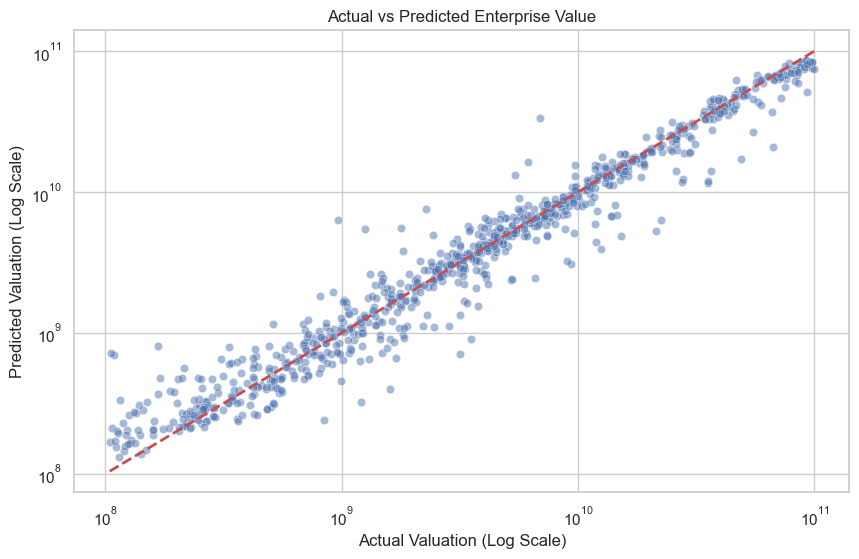

In [13]:
y_pred_df = engine.predict(X_test)
y_pred = y_pred_df["enterprise_value"]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test["enterprise_value"], y=y_pred, alpha=0.5)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'r--', lw=2)
plt.xlabel("Actual Valuation (Log Scale)")
plt.ylabel("Predicted Valuation (Log Scale)")
plt.title("Actual vs Predicted Enterprise Value")
plt.xscale('log')
plt.yscale('log')
plt.show()

/var/folders/wn/w5fg7t9n7hb773n1_40skgk80000gn/T/ipykernel_36142/3326718958.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")


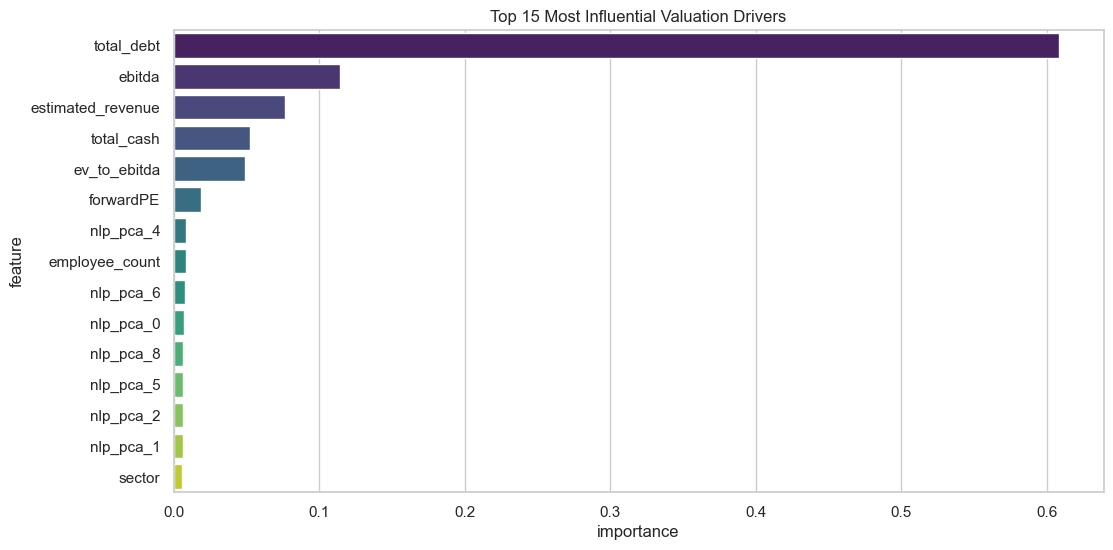

In [58]:
# Feature Importance Analysis
xgb_model = engine.pipeline.named_steps["model"].regressor_

# Reconstruct feature names from the dynamic lists
feature_names = engine.fin_cols + engine.cat_cols + [f"nlp_pca_{i}" for i in range(10)]

importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp_df = feat_imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Most Influential Valuation Drivers")
plt.show()

## 5. Real-World Case Study: Valuation with Sparse Data

In this section, we simulate a real-world scenario where we only have a company's sector, estimated revenue, and its business description (NLP embeddings). We use AnaptysBio, Inc. (ANAB), a mid-sized biotechnology company, as our test case.

In [62]:
# 1. Find ANAB in the original dataset to get its index
df_raw = pd.read_parquet("../data/processed/UNIVERSAL_training.parquet")
case_study_ticker = "VMI"
ticker_row = df_raw[df_raw['ticker'] == case_study_ticker]

if not ticker_row.empty:
    idx = ticker_row.index[0]
    actual_val = ticker_row.iloc[0]['enterprise_value']
    
    # 2. Extract the corresponding row from our embedded dataset (using index)
    # We simulate sparse information by taking the full row and nulling out non-sparse financial features
    case_study_row = df.loc[[idx]].copy()
    
    # Define which columns we want to KEEP for this "sparse" valuation
    keep_cols = ['sector', 'estimated_revenue'] + [f'nlp_{i}' for i in range(384)]
    
    # Null out all other financial columns to simulate missing data
    for col in engine.fin_cols:
        if col not in keep_cols:
            case_study_row[col] = np.nan
    
    print(f"--- Case Study: {case_study_ticker} ---")
    print(f"Sector: {ticker_row.iloc[0]['sector']}")
    print(f"Estimated_revenue: {ticker_row.iloc[0]['estimated_revenue']}")
    print(f"Actual Enterprise Value: ${actual_val:,.0f}")
    print(f"Simulated Inputs: Sector, Estimated Revenue, and Business Summary (NLP)")
    print(f"Dropped Features: {', '.join([c for c in engine.fin_cols if c not in keep_cols])}")
    
    # 3. Predict using the trained engine
    # The pipeline's KNNImputer will handle the NaNs we just introduced
    prediction_df = engine.predict(case_study_row[engine.fin_cols + engine.cat_cols + engine.nlp_cols])
    predicted_val = prediction_df.iloc[0, 0]
    
    error_pct = abs(predicted_val - actual_val) / actual_val * 100
    
    print(f"\nPredicted Enterprise Value: ${predicted_val:,.0f}")
    print(f"Valuation Variance: {error_pct:.2f}%")
    
    # Display the business summary for context
    print(f"\nBusiness Summary snippet:\n{ticker_row.iloc[0]['business_summary'][:300]}...")
else:
    print(f"Ticker {case_study_ticker} not found in dataset.")

--- Case Study: VMI ---
Sector: Industrials
Estimated_revenue: 4163984896.0
Actual Enterprise Value: $10,744,761,344
Simulated Inputs: Sector, Estimated Revenue, and Business Summary (NLP)
Dropped Features: forwardPE, ev_to_ebitda, ebitda, total_cash, total_debt, employee_count

Predicted Enterprise Value: $10,192,714,752
Valuation Variance: 5.14%

Business Summary snippet:
Valmont Industries, Inc. operates as a manufacturer of products and services for infrastructure and agriculture markets in the United States, Australia, Brazil, and internationally. The company operates in two segments, Infrastructure and Agriculture. It manufactures and distributes steel, pre-stres...
